In [7]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
df = pd.read_csv('data/train.csv')
df['file_name'] = df['file_name'].str.replace('train_data', 'data/train_data')


,Unnamed: 0,file_name,label
1,1,data/train_data/041be3153810433ab146bc97d5af50...,0
3,3,data/train_data/8542fe161d9147be8e835e50c0de39...,0
5,5,data/train_data/25ea852f30594bc5915eb929682af4...,0
7,7,data/train_data/041c36d9269146cdb88e7526e3b916...,0
9,9,data/train_data/09708379751e44d0bc908d8652d0db...,0
...,...,...,...
79941,79941,data/train_data/90ffb615d5ad4da7b0b12fc3af7b58...,0
79943,79943,data/train_data/30d00551fd29482e8a6238f623f62c...,0
79945,79945,data/train_data/9283b107f6274279b6f15bbe77c523...,0
79947,79947,data/train_data/1ccbf96d04e342fd9f629ad55466b2...,0


,Unnamed: 0,file_name,label
0,0,data/train_data/a6dcb93f596a43249135678dfcfc17...,1
2,2,data/train_data/615df26ce9494e5db2f70e57ce7a3a...,1
4,4,data/train_data/5d81fa12bc3b4cea8c94a6700a477c...,1
6,6,data/train_data/e67085fb6d814cbabe08f978c738f3...,1
8,8,data/train_data/4aea3b876247467c8d3713d4920148...,1
...,...,...,...
79940,79940,data/train_data/6964d7c333d44633bedecb061f91f4...,1
79942,79942,data/train_data/9508d7fa71c3427f8f69274c34706d...,1
79944,79944,data/train_data/f13ada5be8924de7a3d197b62eb366...,1
79946,79946,data/train_data/4c6b17fe6dd743428a45773135a105...,1


In [48]:
def extract_image_features(file_path):
    bgr = cv2.imread(file_path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # Convert to HLS, HSV, LAB, and YCrCb
    hls = cv2.cvtColor(rgb, cv2.COLOR_RGB2HLS_FULL)
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV_FULL)
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    ycrcb = cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb)

    h, w, _ = rgb.shape
    mean_rgb = np.mean(rgb, axis=(0, 1))
    mean_hls = np.mean(hls, axis=(0, 1))
    mean_v = np.mean(hsv[:, :, 2])
    mean_lab = np.mean(lab, axis=(0, 1))
    mean_ycrcb = np.mean(ycrcb, axis=(0, 1))
    return [h, w, *mean_rgb, *mean_hls, mean_v, *mean_lab, *mean_ycrcb]

columns = ['height', 'width', 'mean_R', 'mean_G', 'mean_B', 'mean_H', 'mean_L', 'mean_S', 'mean_V', 'mean_LAB_L', 'mean_LAB_A', 'mean_LAB_B', 'mean_Y', 'mean_Cr', 'mean_Cb']
df[columns] = df['file_name'].apply(lambda path: pd.Series(extract_image_features(path)))

In [49]:
df_human = df[df['label']==0]
df_ai = df[df['label']==1]
#display(df_human) # 0 = human, 1 = AI
#display(df_ai) # 0 = human, 1 = AI

display(df_human.describe())
display(df_ai.describe())

,Unnamed: 0,label,height,width,mean_R,mean_G,mean_B,mean_H,mean_L,mean_S,mean_V,mean_LAB_L,mean_LAB_A,mean_LAB_B,mean_Y,mean_Cr,mean_Cb
count,39975.000000,39975.0,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000
mean,39975.000000,0.0,569.553171,716.566654,156.803924,147.628319,136.061878,54.137462,146.939490,89.949062,169.534170,155.812541,131.275920,135.933158,149.056143,133.533449,120.663378
std,23079.865684,0.0,118.956644,101.020640,49.825308,46.040022,51.716847,30.513209,46.133308,47.574100,45.391519,45.009062,8.470430,13.448598,45.685650,13.343410,13.941145
min,1.000000,0.0,112.000000,320.000000,1.417531,0.559710,0.786140,0.000000,2.362109,0.000000,3.063568,1.436518,66.284365,55.136851,1.742449,31.092480,13.891088
25%,19988.000000,0.0,512.000000,768.000000,122.062265,116.780938,98.112755,29.517647,114.619150,54.539823,139.765800,126.219093,127.598007,128.394836,117.610926,127.586357,114.172743
50%,39975.000000,0.0,512.000000,768.000000,158.676729,148.468516,137.466743,50.515424,146.321739,82.811050,172.986697,157.293921,130.327924,134.334330,149.183668,132.436019,122.171806
75%,59962.000000,0.0,640.000000,768.000000,196.142964,182.044325,176.288166,74.963364,182.572230,118.681853,204.771987,189.863348,134.464073,142.625612,183.606916,139.640504,127.866212
max,79949.000000,0.0,768.000000,768.000000,254.654482,253.695998,253.833737,177.325911,253.856004,253.616842,254.682362,253.999756,201.765755,216.375511,253.885545,239.112386,204.345701


,Unnamed: 0,label,height,width,mean_R,mean_G,mean_B,mean_H,mean_L,mean_S,mean_V,mean_LAB_L,mean_LAB_A,mean_LAB_B,mean_Y,mean_Cr,mean_Cb
count,39975.000000,39975.0,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000
mean,39974.000000,1.0,569.553171,716.566654,161.332810,154.419127,133.904841,48.797750,148.718837,137.385182,180.029285,161.994396,130.470514,139.920640,154.154311,133.122460,116.574152
std,23079.865684,0.0,118.956644,101.020640,43.848655,40.495461,50.819635,23.309219,40.214693,49.529922,38.227437,38.345730,9.775796,15.462648,39.243437,15.323422,17.238611
min,0.000000,1.0,112.000000,320.000000,3.926692,4.089851,0.797363,0.000000,6.877151,0.000000,8.237147,5.844866,52.540156,48.397239,7.201032,29.707807,1.147952
25%,19987.000000,1.0,512.000000,768.000000,133.833668,129.254881,98.536690,31.071815,121.529012,103.282490,157.312074,138.499184,126.087752,130.535018,129.117772,126.411771,107.954678
50%,39974.000000,1.0,512.000000,768.000000,163.415665,156.721370,136.055617,45.901489,148.659345,140.936063,183.798457,164.047429,130.101463,138.307513,155.225373,133.136180,118.481457
75%,59961.000000,1.0,640.000000,768.000000,193.226799,182.819714,171.645973,62.905208,177.165204,174.204301,207.955590,189.084368,134.757108,148.431582,181.681780,141.260131,126.218843
max,79948.000000,1.0,768.000000,768.000000,254.434491,254.886549,252.968859,171.051682,252.968859,254.937467,254.917808,252.986606,215.553397,222.299674,252.968859,238.436712,220.389794


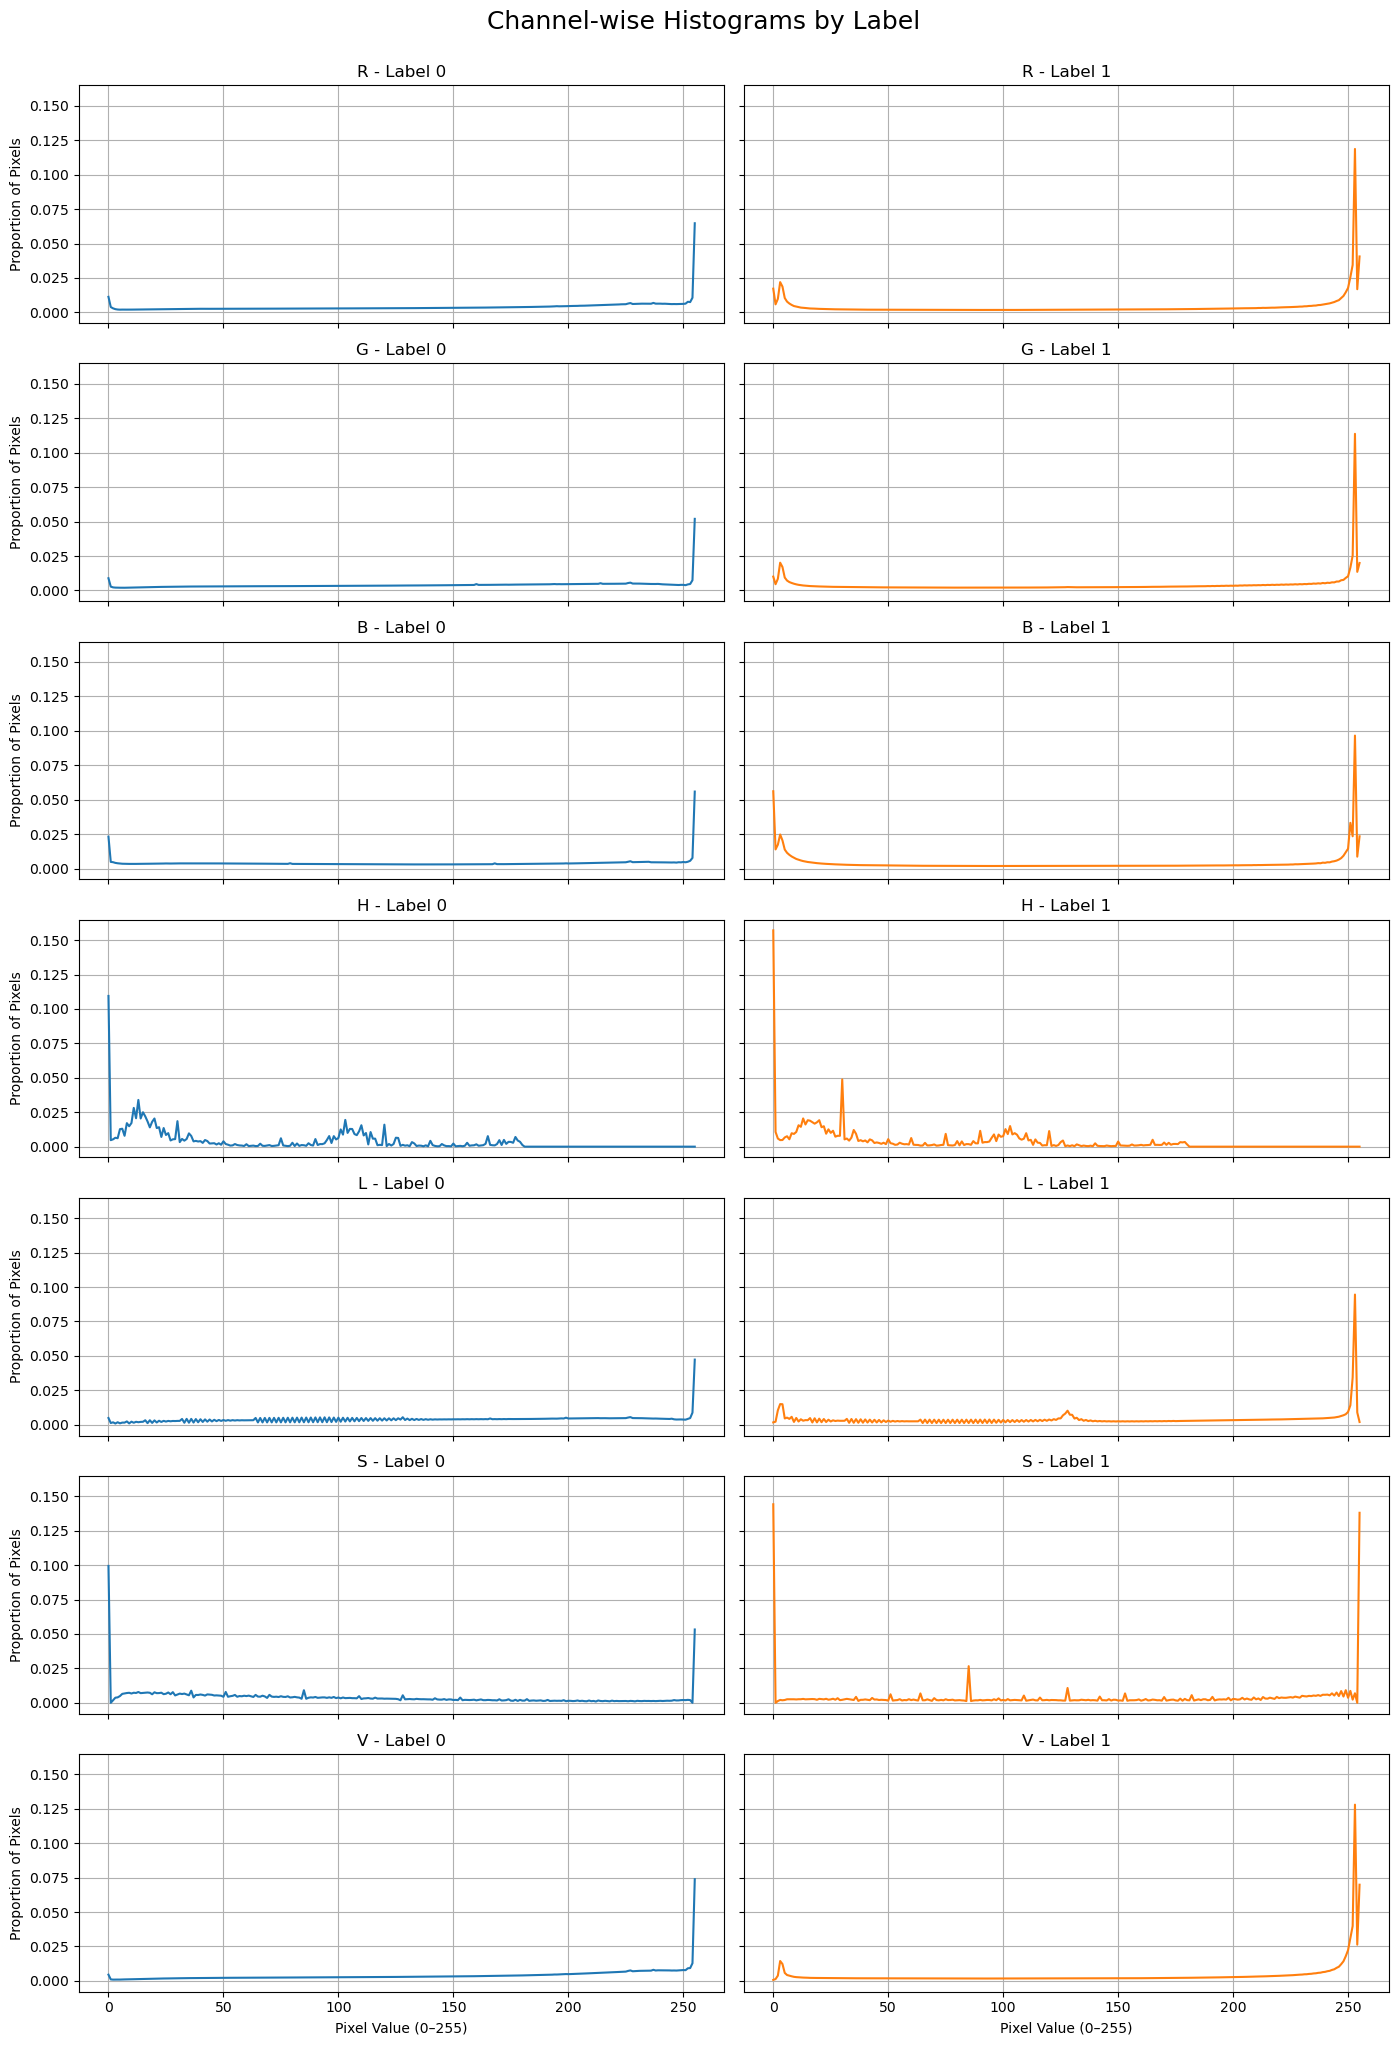

In [73]:
def get_normalized_channel_histograms(file_path):
    bgr = cv2.imread(file_path)
    if bgr is None:
        raise ValueError(f"Image could not be read: {file_path}")

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    hls = cv2.cvtColor(rgb, cv2.COLOR_RGB2HLS)
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)

    r, g, b = cv2.split(rgb)
    h, l, s = cv2.split(hls)
    v = hsv[:, :, 2]

    def norm_hist(channel):
        hist, _ = np.histogram(channel, bins=256, range=(0, 256))
        return hist / hist.sum()

    hist_df = pd.DataFrame({
        'R': norm_hist(r),
        'G': norm_hist(g),
        'B': norm_hist(b),
        'H': norm_hist(h),
        'L': norm_hist(l),
        'S': norm_hist(s),
        'V': norm_hist(v)
    }, index=np.arange(256))

    return hist_df

def compute_histograms_by_label(df):
    histograms = {0: [], 1: []}

    for _, row in df.iterrows():
        file_path = row['file_name']
        label = row['label']
        hist_df = get_normalized_channel_histograms(file_path)
        histograms[label].append(hist_df)


    avg_hist_0 = pd.concat(histograms[0]).groupby(level=0).mean() if histograms[0] else None
    avg_hist_1 = pd.concat(histograms[1]).groupby(level=0).mean() if histograms[1] else None

    return avg_hist_0, avg_hist_1

def plot_each_channel_by_label_separately(avg_hist_0, avg_hist_1):
    channels = avg_hist_0.columns
    fig, axs = plt.subplots(nrows=7, ncols=2, figsize=(14, 20), sharex=True, sharey=True)

    for i, channel in enumerate(channels):
        axs[i, 0].plot(avg_hist_0.index, avg_hist_0[channel], color='tab:blue')
        axs[i, 0].set_title(f'{channel} - Label 0')
        axs[i, 0].set_ylabel("Proportion of Pixels")
        axs[i, 0].grid(True)

        axs[i, 1].plot(avg_hist_1.index, avg_hist_1[channel], color='tab:orange')
        axs[i, 1].set_title(f'{channel} - Label 1')
        axs[i, 1].grid(True)

    for ax in axs[-1]:
        ax.set_xlabel("Pixel Value (0–255)")

    plt.tight_layout()
    plt.suptitle("Channel-wise Histograms by Label", fontsize=18, y=1.02)
    plt.show()

avg_hist_0, avg_hist_1 = compute_histograms_by_label(df)

plot_each_channel_by_label_separately(avg_hist_0, avg_hist_1)



In [75]:
display(avg_hist_0)
display(avg_hist_1)
avg_hist_0.to_csv("avg_hist_0.csv", index=True)
avg_hist_1.to_csv("avg_hist_1.csv", index=True)

,R,G,B,H,L,S,V
0,0.011304,0.008901,0.023158,0.109436,0.004899,0.099400,0.004549
1,0.003902,0.002817,0.004847,0.004720,0.001243,0.000000,0.001098
2,0.002945,0.002260,0.004633,0.005324,0.001768,0.001861,0.000940
3,0.002364,0.002095,0.004122,0.006469,0.000886,0.003724,0.000921
4,0.002097,0.002017,0.003847,0.006138,0.001815,0.003957,0.000977
...,...,...,...,...,...,...,...
251,0.006371,0.003869,0.004572,0.000000,0.003690,0.001969,0.007798
252,0.007726,0.004419,0.004957,0.000000,0.004237,0.002153,0.009166
253,0.007491,0.004705,0.005651,0.000000,0.004837,0.001986,0.009323
254,0.010648,0.007463,0.007733,0.000000,0.008782,0.000000,0.012820


,R,G,B,H,L,S,V
0,0.017247,0.010078,0.056143,0.157028,0.001712,0.144159,0.000734
1,0.005845,0.004551,0.013904,0.010677,0.002216,0.000000,0.001330
2,0.009842,0.008503,0.017327,0.005909,0.010481,0.001298,0.003831
3,0.021992,0.020190,0.024753,0.004758,0.014992,0.002094,0.014447
4,0.018763,0.017061,0.020447,0.004822,0.014905,0.001862,0.012281
...,...,...,...,...,...,...,...
251,0.025603,0.016578,0.033214,0.000000,0.014113,0.008681,0.031145
252,0.034464,0.025327,0.023447,0.000000,0.034364,0.002328,0.039829
253,0.118689,0.113756,0.096565,0.000000,0.094524,0.006947,0.127972
254,0.016840,0.013546,0.008659,0.000000,0.008921,0.000000,0.026318
